# What are embeddings
### Think of embeddings as a way to translate words into a langunage that computers can understand- numbers !

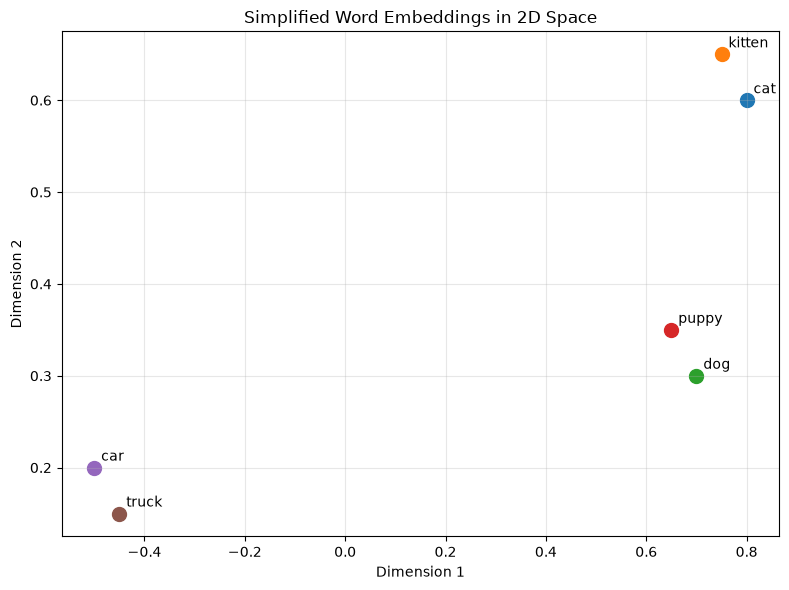

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Simplified 2D example
# Real embeddings have hundreds of dimensions

word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}



fig, ax = plt.subplots(figsize=(8, 6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(
        word,
        (coords[0], coords[1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title("Simplified Word Embeddings in 2D Space")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np

def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angle between two vectors.

    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposite meanings
    """

    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)

    return dot_product / (norm_a * norm_b)


# Example

cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(
    cat_vector,
    kitten_vector
)

print(cat_kitten_similarity)
print(cosine_similarity(cat_vector, car_vector))

0.9966186334192183
-0.4371858854891681


# Creating Your First Embeddings

In [5]:
### Huggingface and openai models
from langchain_huggingface import HuggingFaceEmbeddings

## Intialize simple embedding model (no API key needed!)
emeddings = HuggingFaceEmbeddings(
    model_name = 'sentence-transformers/all-MiniLM-L6-v2'
)
emeddings


d:\UdemyRAG\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dell\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3757.75it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [11]:
# create your first embedding
text = "Hello, I am leaning about embeddings!"
embedding=emeddings.embed_query(text)
print(f"Text:{text}")
print(f"embedding length {len(embedding)}")
print(embedding)



Text:Hello, I am leaning about embeddings!
embedding length 384
[-0.048854660242795944, -0.09809291362762451, 0.0004350643721409142, -0.019097141921520233, 0.027724910527467728, 0.05999239161610603, -0.05089281126856804, 0.004839348141103983, 0.03699127957224846, 0.0033519582357257605, -0.0016792218666523695, 0.10547982156276703, 0.045851930975914, 0.06308548152446747, -0.0037567659746855497, 0.006061511114239693, 0.06526338309049606, 0.10573175549507141, -0.015171511098742485, 0.05171333625912666, -0.06110406666994095, -0.04545539617538452, 0.030162109062075615, -0.09600493311882019, 0.021743088960647583, -0.014662418514490128, -0.043014444410800934, 0.053271058946847916, 0.0578954815864563, -0.10463205724954605, 0.042575374245643616, -0.008654283359646797, -0.03984841704368591, 0.035617709159851074, -0.04527901113033295, 0.07591895014047623, 0.03280320018529892, -0.007786417379975319, -0.06495712697505951, -0.03832783177495003, -0.021631306037306786, 0.04751957207918167, -0.011640461

In [15]:
 
sentences = [
    "The cat sat on the mat",
    "A feline rested on the rug",
    "The dog played in the yard",
    "I love programming in python",
    "Python is my favorite programming language"
]

embedding_sentence = emeddings.embed_documents(sentences)

print(embedding_sentence)

[[0.13040179014205933, -0.011870082467794418, -0.028117064386606216, 0.05123867094516754, -0.055974461138248444, 0.030191533267498016, 0.030161313712596893, 0.02469841204583645, -0.018370570614933968, 0.05876680091023445, -0.024953201413154602, 0.06015423685312271, 0.03983177989721298, 0.0332304984331131, -0.061311401426792145, -0.04937313497066498, -0.054863546043634415, -0.040076106786727905, 0.05642914026975632, 0.039156556129455566, -0.03473712503910065, -0.013247662223875523, 0.0319662019610405, -0.06349921971559525, -0.06017858162522316, 0.07823453098535538, -0.028303852304816246, -0.047442883253097534, 0.040359269827604294, -0.006630906835198402, -0.066740982234478, -0.0041913059540092945, -0.02531164512038231, 0.05334165692329407, 0.017428087070584297, -0.09792359918355942, 0.006061331368982792, -0.06524167209863663, 0.04557260125875473, 0.023641841486096382, 0.07658485323190689, -0.010264329612255096, -0.004076807759702206, -0.06232282146811485, 0.03370523452758789, 0.01866114